In [1]:
from collections import Counter
import cirq
from cirq.contrib.svg import SVGCircuit
import warnings
import sys
import matplotlib.pyplot as plt

sys.path.append("../")
import resource_estimation as res
import scripts.layout_figures as lfs


warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)
_COLORS = {
    "None": "#ffffff",
    "T Factory": "#4ddef1",
    "S Factory": "#fcc084",
    "Data Qubit": "#a4f0c2",
    "Ancilla Patch": "#f5bad6",
    "Distillation": "#E6E6FA",
    "CNOT": "#ed6340",
    "Toff Factory": "#000000",
}
_PRETTY = True  # I don't think the SVG circuits are pretty, but this is an option
cast_circuit = lambda circuit: (
    SVGCircuit(circuit) if _PRETTY else circuit
)  # A cirq contribution's version of 'pretty'

# Overview
This notebook shows how to use `resource-superstaq` to estimate quantum resources when using distillation.  For the case of distilling T states only, one can pass in an arbitrary cirq circuit.  To estimate resouces using T and/or CCZ states, the circuit must be expressed in terms of T, S, CNOT, H, and TOFFOLI gates.  That is, the circuit has already been cast in terms of Clifford+T+Toffoli.   Currently, only Movement Architectures and the `MovementDistillery` layout support distillation.  The key metrics will be physical qubits, circuit runtime, and physical operation count. The basic flow is shown below:
- Have a `cirq` circuit
- Choose a Movement Architecture
    - Single Species with Movement (`DefaultMovement`) (SSM)
    - Dual Species with Movement (DSM)
- Use the Distillation Layout
    - Use `MovementDistillery` for SSM or DSM
- Compile Clifford + T + Toffoli circuit to Primitives
    -  Primitives are Gate-like objects with simple physical decompositions
    -  This step includes operations for movement for movement-based architectures
- Estimate Resources
    - Count gates by unrolling gate costs for primitives
    - Extract time by unrolling gate times for primitives

Here we will first give an example using only T-state distillation, then a second example using T and CCZ-state distillation.


# Distillation with T states

## Have a Circuit
For this example, we use a random unitary

In [2]:
qubits = 3
U = cirq.testing.random_unitary(dim=2**qubits, random_state=7)
circuit = cirq.Circuit(cirq.MatrixGate(U).on(*cirq.LineQubit.range(qubits)))
circuit

┌                                                                     ┐
      │ 0.385-0.087j -0.242-0.314j -0.212-0.333j  0.052-0.213j -0.124-0.348j│
      │  -0.062+0.076j  0.207+0.438j -0.318-0.045j                          │
      │ 0.232+0.025j  0.152+0.443j -0.087+0.353j  0.201-0.371j -0.004-0.037j│
      │  -0.145+0.237j -0.135-0.153j -0.437-0.323j                          │
      │ 0.126+0.149j  0.03 +0.25j   0.136+0.067j -0.383-0.487j  0.256-0.094j│
      │  -0.297-0.194j  0.28 +0.201j  0.413+0.045j                          │
      │-0.01 +0.348j -0.438+0.149j -0.048+0.187j -0.394+0.339j  0.259-0.163j│
0: ───│  -0.144+0.023j -0.256+0.088j -0.343+0.227j                          │───
      │-0.376+0.514j  0.308+0.218j -0.262-0.207j -0.119+0.015j -0.239+0.161j│
      │   0.156+0.172j  0.231+0.337j -0.133-0.069j                          │
      │ 0.191+0.111j -0.087-0.23j   0.052+0.309j -0.136+0.011j -0.591+0.344j│
      │  -0.323+0.072j -0.295+0.247j  0.202-0.087j                          │
      │ 0.061+0.24j  -0.16 +0.129j  0.546-0.34j   0.047-0.052j -0.335+0.113j│
      │  -0.144-0.314j  0.188-0.308j -0.315+0.054j                          │
      │-0.327-0.089j  0.223-0.225j  0.007+0.168j  0.256+0.128j  0.135+0.005j│
      │  -0.694+0.033j  0.287+0.068j -0.206+0.21j                           │
      └                                                                     ┘
      │
1: ───#2────────────────────────────────────────────────────────────────────────
      │
2: ───#3────────────────────────────────────────────────────────────────────────

## Compile to Clifford + Rz
Each application circuit generally does not come packaged neatly in a fault tolerant gateset, so we use an intermediate compilation step that converts the circuit to the Clifford + Rz gateset using local Cirq-based optimization (via `resource_estimation.compile_gateset.compile_gateset`, which wraps `cirq.optimize_for_target_gateset` for Cirq gatesets). This process can have the effect of magnifying inefficiencies that might have already existed in the input circuit. This is just a demonstration.

In [3]:
cliff_rz_circuit = res.compile_gateset.compile_gateset(
    circuit,
    gateset=res.compile_gateset.clifford_rz_gateset(),
)

In [4]:
print(f"Qubits: {cirq.num_qubits(cliff_rz_circuit)}")
print(f"Moments: {len(cliff_rz_circuit)}")

Qubits: 3
Moments: 95


In [5]:
print(f"Moments:{' ' * (10 - len(str(len(cliff_rz_circuit))))}{len(cliff_rz_circuit)}")
grouped_ops = Counter(
    str(op.gate) if op.gate not in cirq.GateFamily(cirq.Rz) else "Rz"
    for op in cliff_rz_circuit.all_operations()
)
for key, val in grouped_ops.items():
    if "Measurement" in key:
        key = "Measurement"
    print(f"{key}{' ' * (16 - len(key))}{val}")

Moments:        95
Rz              75
H               60
CNOT            20
Z               5
S               1


## Synthesize Circuit
We can use `pygridsynth` to compile the Rz gates generated in the previous step to strings of H, S, and T. The input parameter epsilon plays the main role in determining the length of these strings. In practice, we can choose this parameter based on the number Rz gates in the circuit and the program fidelity we would like. To keep things simple, we choose a program fidelity of 99%. The higher the requested fidelity, the more expensive the synthesis becomes.

In [6]:
eps = 1 - 0.99 ** (1 / grouped_ops["Rz"])
synthesized_circuit = res.compile_gateset.compile_gateset(
    cliff_rz_circuit,
    gateset=res.compile_gateset.clifford_t_gateset(atol=eps),
)

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 95/95 [00:01<00:00, 84.99it/s]


In [7]:
print(f"Moments:{' ' * 12}{len(synthesized_circuit)}")
grouped_ops = Counter(str(op.gate) for op in synthesized_circuit.all_operations())
for key, val in grouped_ops.items():
    if "Measurement" in key:
        key = "Measurement"
    print(f"{key}{' ' * (20 - len(key))}{val}")

Moments:            4537
X                   31
S                   1653
T                   3068
H                   3178
CNOT                20
Z                   5


## Choose an Architecture

In [8]:
ssm = res.ftqc.DefaultMovement(
    d=11,  # Rotated Surface Code code distance
    idling=False,  # Include Syndrome Extraction on idling qubits in compiled circuit
    post_op_correction=True,  # Turn on or off Syndrome Extraction after transversal operations
    syndrome_rounds=1,  # Rounds of Syndrome Extraction after transversal operations
    cultivation_repetition=1,  # Expected repetitions of the cultivation circuit to get a successful T state
    distillation_repetition=1,  # Expected repetitions of the distillation circuit to get a successful T state
)

## Choose a Layout

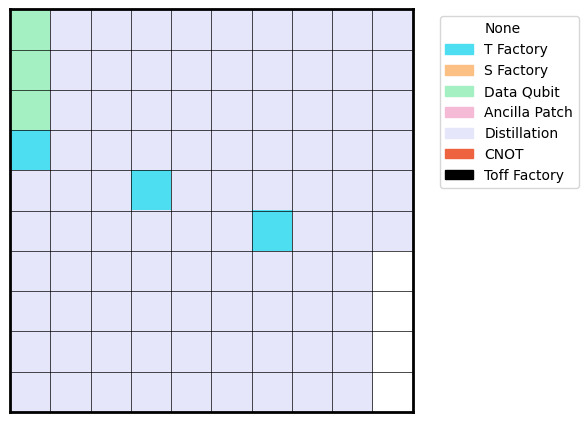

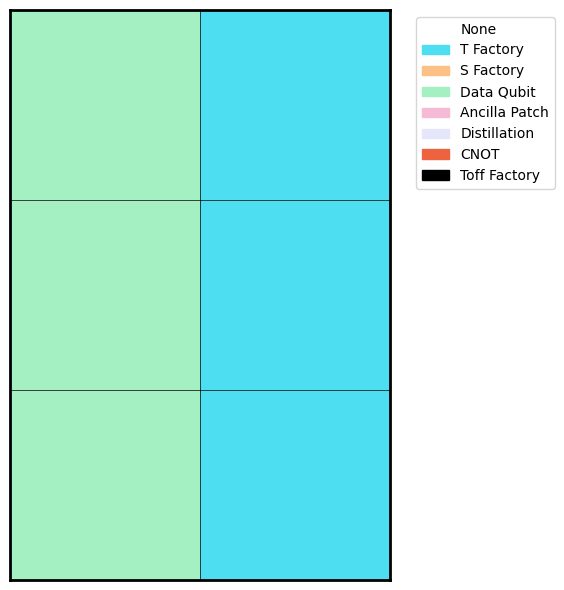

In [9]:
# Use a layout for distillation
distillation_layout = res.ftqc.layout.MovementDistillery(
    input_circuit=synthesized_circuit, num_t_factories=3
)
fig, ax, im = lfs.plot_layout(distillation_layout, category_colors=_COLORS, transpose=True)
# Use a layout for cultivation
cultivation_layout = res.ftqc.MovementLayout(input_circuit=synthesized_circuit, num_t_factories=3)
fig, ax, im = lfs.plot_layout(cultivation_layout, category_colors=_COLORS, transpose=True)

## FT Compile

In [10]:
# Compile the circuit for distillation
primitive_circuit_for_distillation = res.ftqc.ft_compile(
    layout=distillation_layout, arc=ssm, verbose=True
)

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 7955/7955 [00:00<00:00, 847813.20it/s]


In [11]:
# Compile the circuit for cultivation
primitive_circuit_for_cultivation = res.ftqc.ft_compile(
    layout=cultivation_layout, arc=ssm, verbose=True
)

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 7955/7955 [00:00<00:00, 791537.69it/s]


## Estimate Resources

In [12]:
# Distillation estimates
estimator = res.ftqc.ResourceEstimator(arc=ssm)
gate_cost = estimator.parallel_circuit_cost(primitive_circuit_for_distillation, pretty=True)
circuit_time = estimator.parallel_circuit_time(primitive_circuit_for_distillation)
physical_qubits = estimator.physical_qubits(primitive_circuit_for_distillation)

In [13]:
print("Gates")
for op, count in sorted(gate_cost.items(), key=lambda x: x[1], reverse=True):
    print(f"{op}{' ' * (25 - len(op))}{count:.2e}")
print("*" * 33)
print("Metrics")
print(f"Time (μs){' ' * 16}{circuit_time:.2e}\nQubits{' ' * 19}{physical_qubits:.2e}")
print("*" * 33)

Gates
QubitPermutationGate     3.47e+05
CZ                       1.51e+05
PhasedXZGate             4.92e+04
ResetChannel             2.15e+04
MeasurementGate          2.15e+04
*********************************
Metrics
Time (μs)                2.04e+08
Qubits                   2.31e+04
*********************************


In [14]:
# Cultivation estimates
gate_cost = estimator.parallel_circuit_cost(primitive_circuit_for_cultivation, pretty=True)
circuit_time = estimator.parallel_circuit_time(primitive_circuit_for_cultivation)
physical_qubits = estimator.physical_qubits(primitive_circuit_for_cultivation)

In [15]:
print("Gates")
for op, count in sorted(gate_cost.items(), key=lambda x: x[1], reverse=True):
    print(f"{op}{' ' * (25 - len(op))}{count:.2e}")
print("*" * 33)
print("Metrics")
print(f"Time (μs){' ' * 16}{circuit_time:.2e}\nQubits{' ' * 19}{physical_qubits:.2e}")
print("*" * 33)

Gates
QubitPermutationGate     3.32e+05
CZ                       1.46e+05
PhasedXZGate             4.35e+04
ResetChannel             2.07e+04
MeasurementGate          1.96e+04
*********************************
Metrics
Time (μs)                1.94e+08
Qubits                   1.45e+03
*********************************


# Distillation with T and CCZ states

## Have a Circuit
For this example, we use a random unitary made of only Cliffords+T+Toffoli

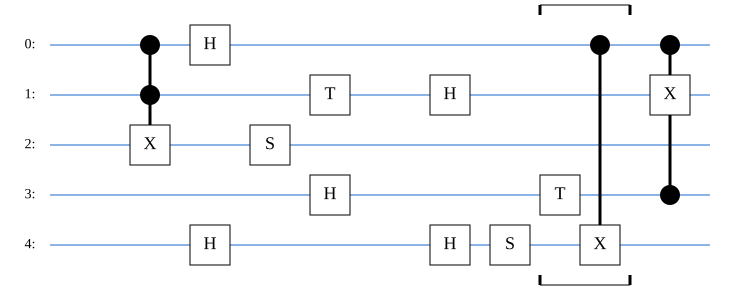

In [16]:
qubits = 5


def make_test_circuit(num_qubits) -> cirq.Circuit:
    circuit = cirq.testing.random_circuit(
        cirq.LineQubit.range(num_qubits),
        10,
        0.6,
        {cirq.T: 1, cirq.S: 1, cirq.CNOT: 2, cirq.H: 1, cirq.TOFFOLI: 3},
        44,
    )
    return circuit


circuit = make_test_circuit(qubits)
cast_circuit(circuit)  # This circuit is only composed of Cliffords, Ts, and Toffolis

## Choose a Movement Architecture

In [17]:
ssm = res.ftqc.DefaultMovement(
    d=11,  # Rotated Surface Code code distance
    idling=False,  # Include Syndrome Extraction on idling qubits in compiled circuit
    post_op_correction=True,  # Turn on or off Syndrome Extraction after transversal operations
    syndrome_rounds=1,  # Rounds of Syndrome Extraction after transversal operations
    cultivation_repetition=5,  # Expected repetitions of the cultivation circuit to get a successful T state
    distillation_repetition=1,  # Expected repetitions of the distillation circuits to get a successful T and Toffoli state
)
estimator = res.ftqc.ResourceEstimator(arc=ssm)  # Create an estimator object
# Notice the T-states used as input for distillation come from cultivation

## Choose a Layout

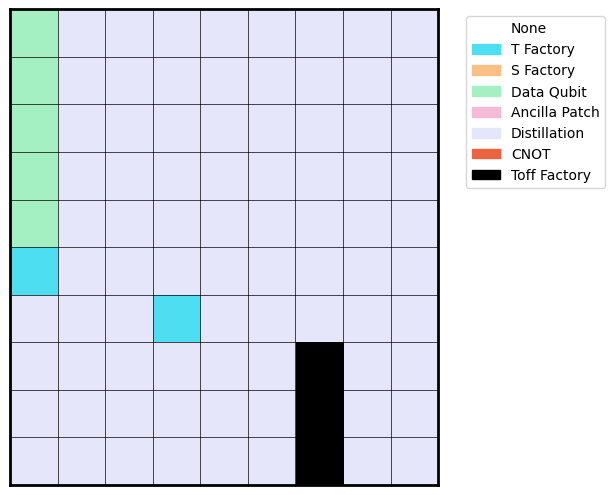

In [18]:
layout = res.ftqc.layout.MovementDistillery(
    input_circuit=circuit, num_t_factories=2, num_toff_factories=1
)
fig, ax, im = lfs.plot_layout(layout, category_colors=_COLORS, transpose=True)

## FT Compile

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 12/12 [00:00<00:00, 197379.01it/s]


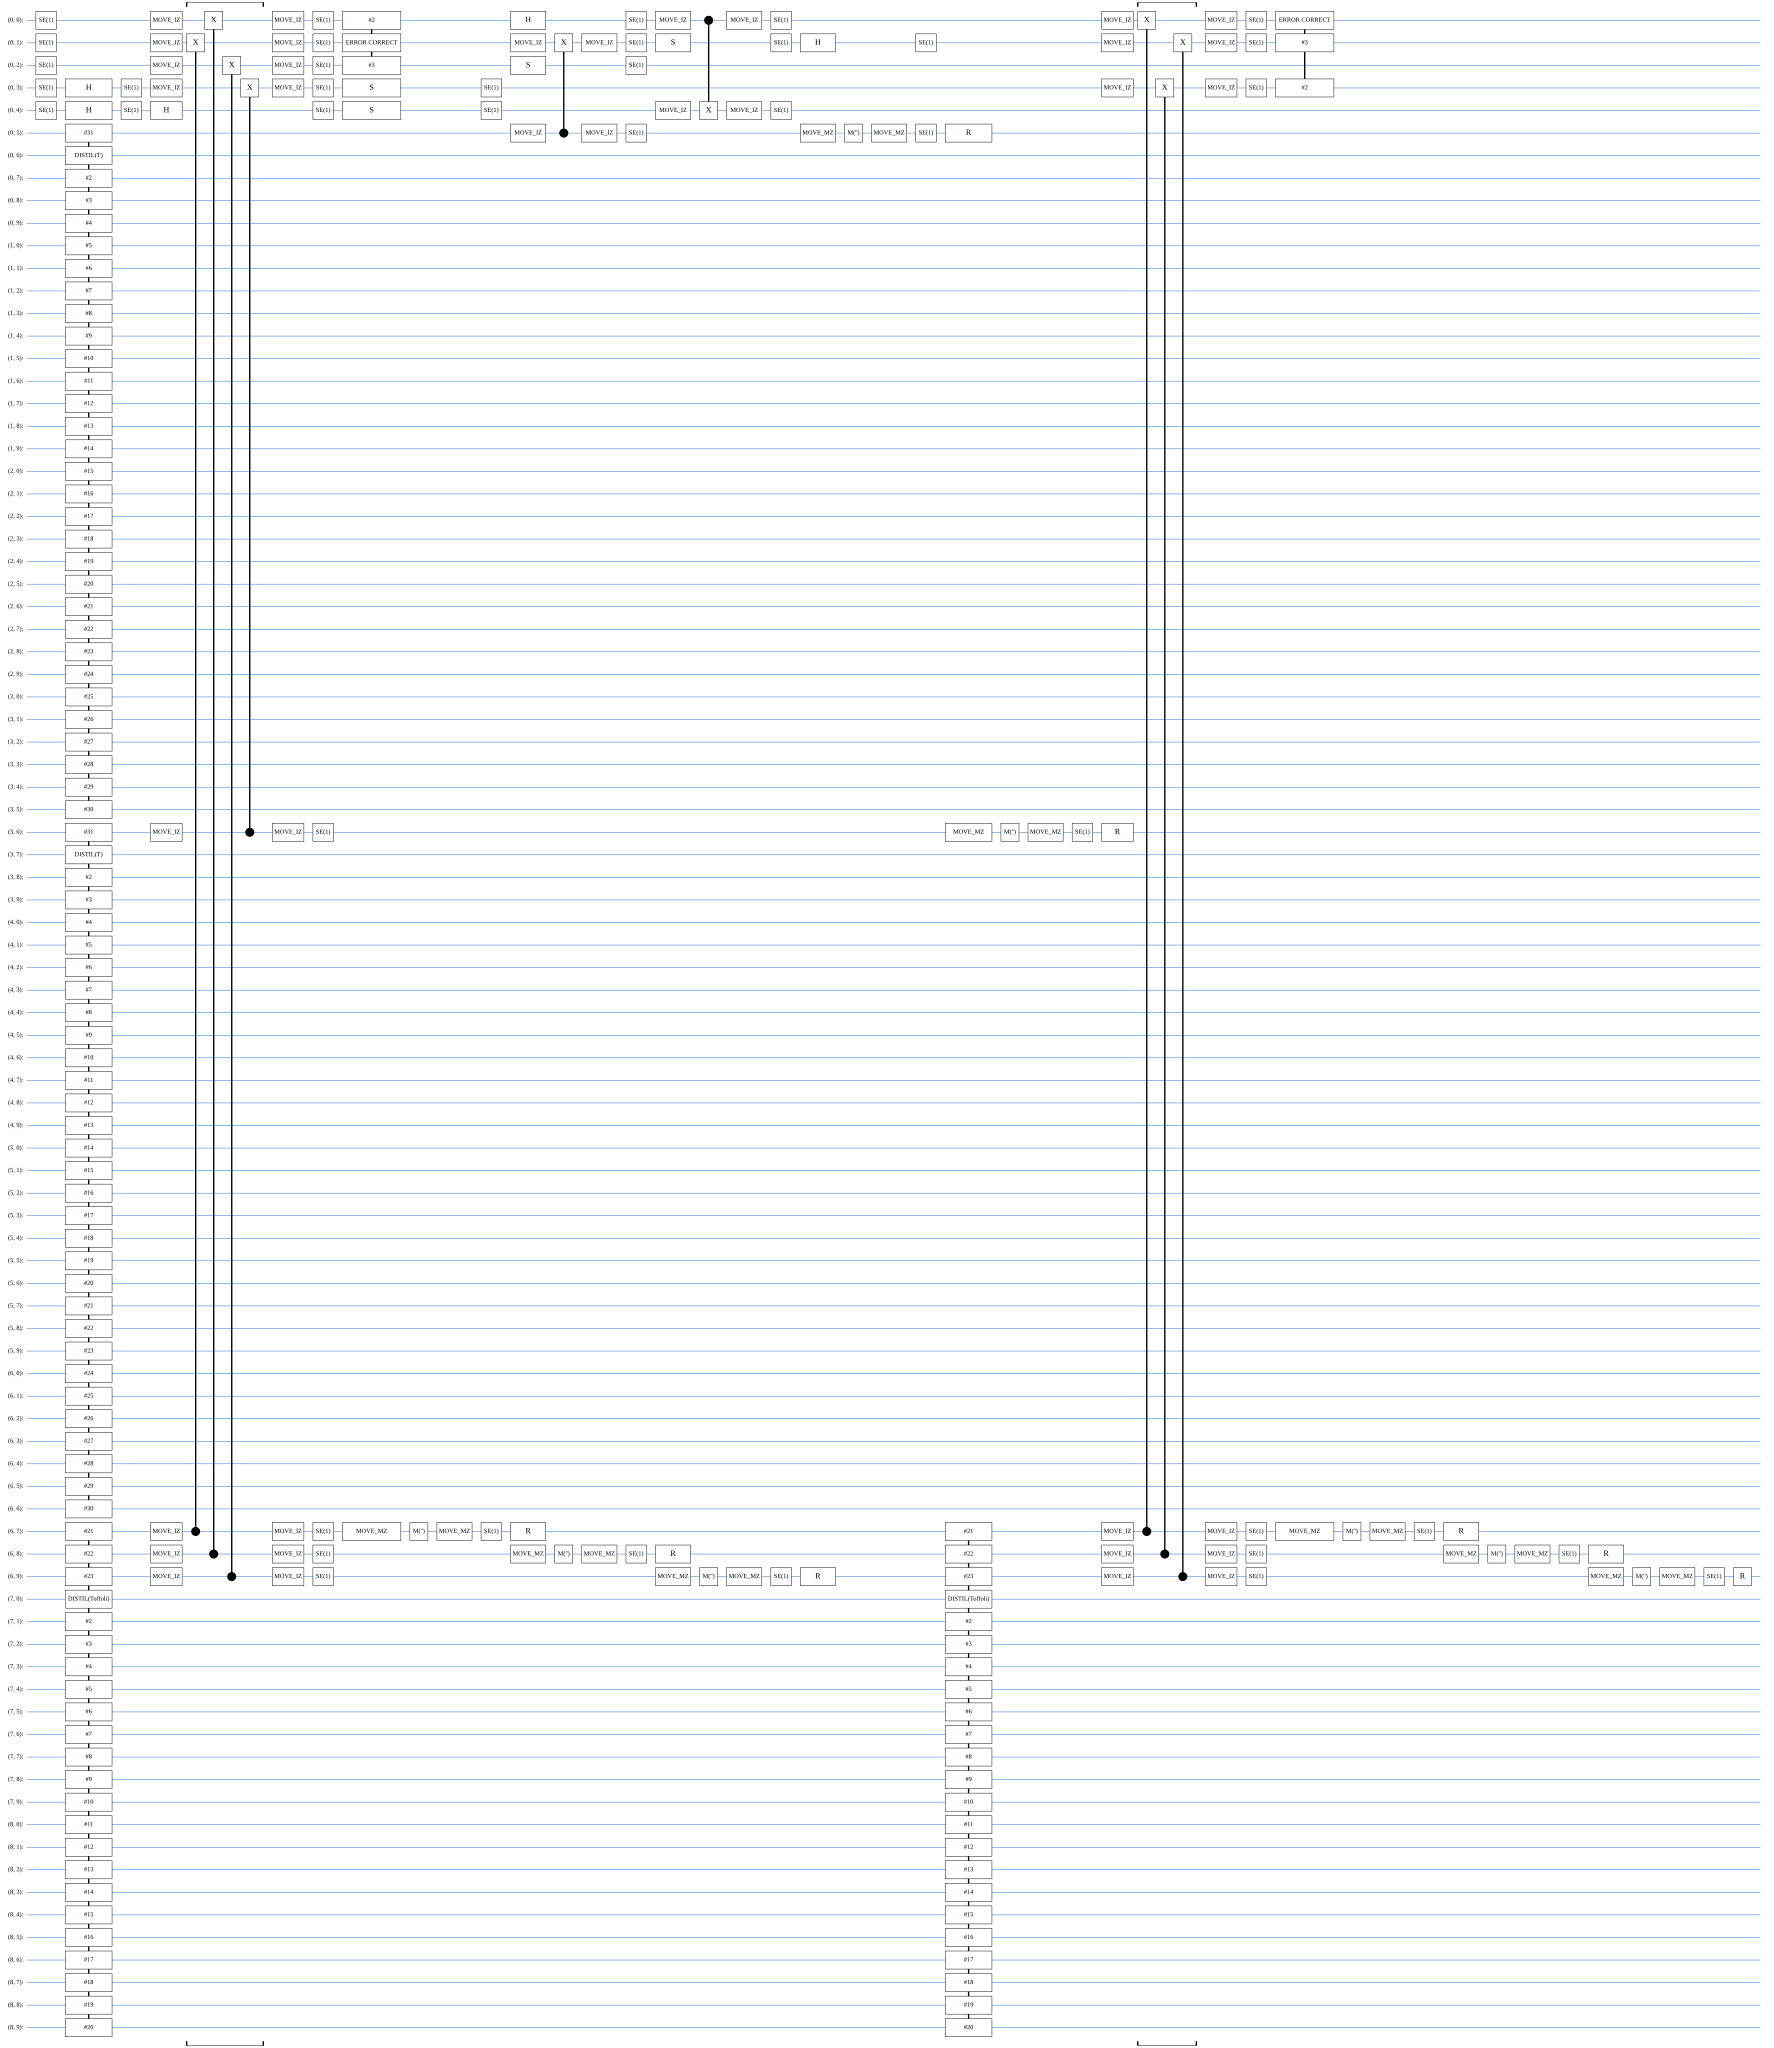

In [19]:
# Recompile the circuit in terms of primitives
primitive_circuit = res.ftqc.ft_compile(layout=layout, arc=ssm, verbose=True)
cast_circuit(primitive_circuit)

In [20]:
# Primitive gate counts
primitive_gate_counts = Counter(
    [
        "Measure" if op in cirq.GateFamily(cirq.MeasurementGate) else str(op.gate)
        for op in primitive_circuit.all_operations()
    ]
)
print("Primitive gate counts")
for op, count in sorted(primitive_gate_counts.items(), key=lambda x: x[1], reverse=True):
    print(f"{op}{' ' * (25 - len(op))}{count}")

Primitive gate counts
SE(1)                    40
MOVE_IZ                  36
MOVE_MZ                  16
CNOT                     9
Measure                  8
reset                    8
H                        5
S                        4
DISTIL(Toffoli)          2
DISTIL(T)                2
ERROR CORRECT            2


In [21]:
# Primitives in the critical path
primitive_cost = estimator.critical_path(primitive_circuit)
primitive_counts = Counter(
    [
        "Measure" if primitive in cirq.GateFamily(cirq.MeasurementGate) else str(primitive.gate)
        for primitive in primitive_cost
    ]
)
print("Critical path primitives")
for op, count in sorted(primitive_counts.items(), key=lambda x: x[1], reverse=True):
    print(f"{op}{' ' * (25 - len(op))}{count}")

Critical path primitives
MOVE_IZ                  4
SE(1)                    4
MOVE_MZ                  4
DISTIL(Toffoli)          2
CNOT                     2
Measure                  2
reset                    2


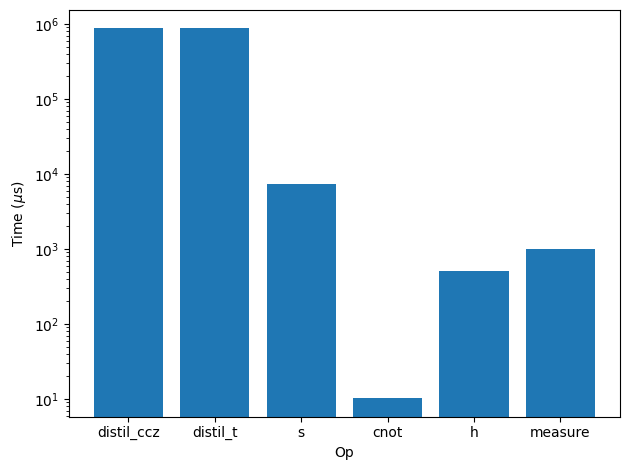

In [22]:
# We see distil_t is the largest cost in time
op_times = [
    ssm._distil_cost("Toffoli")["op_time"],
    ssm._distil_cost("T")["op_time"],
    ssm._s_cost["op_time"],
    ssm._cnot_cost["op_time"],
    ssm._h_cost["op_time"],
    ssm._measure_cost["op_time"],
]
op_names = [
    "distil_ccz",
    "distil_t",
    "s",
    "cnot",
    "h",
    "measure",
]
f, ax = plt.subplots()
ax.bar(op_names, op_times)
ax.set_xlabel("Op")
ax.set_ylabel(r"Time ($\mu$s)")
ax.set_yscale("log")
plt.tight_layout()
plt.show()

## Estimate Resources

In [23]:
# Extract the various costs
gate_cost = estimator.parallel_circuit_cost(primitive_circuit, pretty=True)
circuit_time = estimator.parallel_circuit_time(primitive_circuit)
physical_qubits = estimator.physical_qubits(primitive_circuit)

In [24]:
print("Gates")
for op, count in sorted(gate_cost.items(), key=lambda x: x[1], reverse=True):
    print(f"{op}{' ' * (25 - len(op))}{count}")
print("*" * 33)
print("Metrics")
print(f"Time (μs){' ' * 16}{circuit_time:.2e}\nQubits{' ' * 19}{physical_qubits:.2e}")
print("*" * 33)

Gates
QubitPermutationGate     96
PhasedXZGate             56
CZ                       38
ResetChannel             8
MeasurementGate          8
*********************************
Metrics
Time (μs)                1.77e+06
Qubits                   2.17e+04
*********************************
